<a href="https://colab.research.google.com/github/varazianavsa/05-08-2025/blob/main/data_siswa_salsabilaabhista.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# membaca data
df = pd.read_excel("/content/dataset_nilai_akademik_siswa.xlsx")

print("Data berhasil dibaca")
display(df.head())

In [ ]:
# melihat informasi data
print("Jumlah baris dan kolom:", df.shape)

print("\nNama kolom:")
print(df.columns.tolist())

print("\nInformasi data:")
df.info()

Jumlah baris dan kolom: (79, 8)

Nama kolom:
['id_siswa', 'nama', 'kelas', 'mata_pelajaran', 'jenis_ujian', 'tanggal_ujian', 'nilai', 'guru_pengampu']

Informasi data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_siswa        79 non-null     object        
 1   nama            79 non-null     object        
 2   kelas           79 non-null     object        
 3   mata_pelajaran  79 non-null     object        
 4   jenis_ujian     79 non-null     object        
 5   tanggal_ujian   79 non-null     datetime64[ns]
 6   nilai           75 non-null     object        
 7   guru_pengampu   75 non-null     object        
dtypes: datetime64[ns](1), object(7)
memory usage: 5.1+ KB


In [ ]:
# mengecek data kosong dan duplikat
print("Data kosong:")
print(df.isnull().sum())#untuk mengecek apakah ada data yang ksosng dan menjumlah data kososng pada setiap kolom

print("\nData duplikat:", df.duplicated().sum()) #untuk menghitung data yang sama

Data kosong:
id_siswa          0
nama              0
kelas             0
mata_pelajaran    0
jenis_ujian       0
tanggal_ujian     0
nilai             4
guru_pengampu     4
dtype: int64

Data duplikat: 4


In [ ]:
# membersihkan data nilai
df["nilai"] = (
    df["nilai"]
    .astype(str)#menguba kolom nilai menjadi teks
    .str.extract(r"(\d+\.?\d*)")[0] #mengambil angka dari teks
)

df["nilai"] = pd.to_numeric(df["nilai"], errors="coerce")#nilai menjadi angka

# menghapus nilai yang tidak masuk akal
df.loc[df["nilai"] > 100, "nilai"] = None #jika nilai nya lebih dari 100 kita anggap tidak valid
df.loc[df["nilai"] < 0, "nilai"] = None

# mengisi nilai kosong dengan rata-rata
df["nilai"] = df["nilai"].fillna(df["nilai"].mean())

display(df.head())

,id_siswa,nama,kelas,mata_pelajaran,jenis_ujian,tanggal_ujian,nilai,guru_pengampu
0,SIS0004,Joko Prasetyo,XI RPL 2,KKA,uas,2026-08-06,46.0,Ibu Wati
1,SIS0020,Eka Putri,XI RPL 1,PKK,uts,2026-08-12,73.0,Bpk. Santoso
2,SIS0015,Nanda Pratama,XI RPL 3,Pemrograman Web,UAS,2026-08-15,69.0,Bpk. Santoso
3,SIS0046,Fajar Nugroho,XI RPL 2,Matematika,UH,2026-08-10,73.0,Bpk. Arifin
4,SIS0011,Ayu Lestari,XI RPL 2,Pemrograman Web,UH,2026-08-06,53.0,Ibu Wati


In [ ]:
# merapikan data teks
kolom = [
    "nama",
    "kelas",
    "mata_pelajaran",
    "jenis_ujian",
    "guru_pengampu"
]

for i in kolom:
    df[i] = df[i].astype("string").str.strip()

df["jenis_ujian"] = df["jenis_ujian"].str.upper()

print("Data setelah dibersihkan:")
display(df.head())

Data setelah dibersihkan:


,id_siswa,nama,kelas,mata_pelajaran,jenis_ujian,tanggal_ujian,nilai,guru_pengampu
0,SIS0004,Joko Prasetyo,XI RPL 2,KKA,UAS,2026-08-06,46.0,Ibu Wati
1,SIS0020,Eka Putri,XI RPL 1,PKK,UTS,2026-08-12,73.0,Bpk. Santoso
2,SIS0015,Nanda Pratama,XI RPL 3,Pemrograman Web,UAS,2026-08-15,69.0,Bpk. Santoso
3,SIS0046,Fajar Nugroho,XI RPL 2,Matematika,UH,2026-08-10,73.0,Bpk. Arifin
4,SIS0011,Ayu Lestari,XI RPL 2,Pemrograman Web,UH,2026-08-06,53.0,Ibu Wati


In [ ]:
# statistik nilai
print("Rata-rata nilai:", round(df["nilai"].mean(), 2))
print("Nilai tertinggi:", df["nilai"].max())
print("Nilai terendah:", df["nilai"].min())

print("\nStatistik nilai:")
print(df["nilai"].describe())

NameError: name 'df' is not defined

In [ ]:
# rata-rata nilai berdasarkan kelas
rata_kelas = df.groupby("kelas")["nilai"].mean()

print(rata_kelas)

kelas
XI RPL 1    67.373874
XI RPL 2    68.636824
XI RPL 3    61.625994
Name: nilai, dtype: float64


In [ ]:
# rata-rata nilai berdasarkan mata pelajaran
rata_mapel = df.groupby("mata_pelajaran")["nilai"].mean()

print(rata_mapel)

mata_pelajaran
Bahasa Inggris     66.897683
Basis Data         59.944906
KKA                64.250000
Matematika         70.017736
PKK                63.312500
Pemrograman Web    67.037838
Name: nilai, dtype: float64


In [ ]:
# rata-rata nilai berdasarkan jenis ujian
rata_ujian = df.groupby("jenis_ujian")["nilai"].mean()

print(rata_ujian)

jenis_ujian
UAS    61.010915
UH     71.542793
UTS    61.950059
Name: nilai, dtype: float64


In [ ]:
# membuat kategori nilai
def kategori(nilai):
    if nilai >= 90:
        return "Sangat Baik"
    elif nilai >= 80:
        return "Baik"
    elif nilai >= 70:
        return "Cukup"
    else:
        return "Perlu Perbaikan"

df["kategori_nilai"] = df["nilai"].apply(kategori)

display(
    df[["nama", "kelas", "nilai", "kategori_nilai"]].head(10)
)

,nama,kelas,nilai,kategori_nilai
0,Joko Prasetyo,XI RPL 2,46.0,Perlu Perbaikan
1,Eka Putri,XI RPL 1,73.0,Cukup
2,Nanda Pratama,XI RPL 3,69.0,Perlu Perbaikan
3,Fajar Nugroho,XI RPL 2,73.0,Cukup
4,Ayu Lestari,XI RPL 2,53.0,Perlu Perbaikan
5,Maya Anggraini,XI RPL 2,42.0,Perlu Perbaikan
6,Gita Ramadhani,XI RPL 3,45.0,Perlu Perbaikan
7,Indah Permata,XI RPL 1,74.0,Cukup
8,Putri Amelia,XI RPL 1,98.0,Sangat Baik
9,Eka Putri,XI RPL 1,56.0,Perlu Perbaikan


In [ ]:
# jumlah siswa berdasarkan kategori
print(df["kategori_nilai"].value_counts())

kategori_nilai
Perlu Perbaikan    51
Cukup              17
Sangat Baik         8
Baik                3
Name: count, dtype: int64


In [ ]:
# 10 nilai tertinggi
data_tertinggi = df.sort_values(
    by="nilai",
    ascending=False
).head(10)

display(data_tertinggi)

,id_siswa,nama,kelas,mata_pelajaran,jenis_ujian,tanggal_ujian,nilai,guru_pengampu,kategori_nilai
35,SIS0037,Hendra Wijaya,XI RPL 2,Matematika,UH,2026-08-13,100.0,Bpk. Arifin,Sangat Baik
34,SIS0037,Hendra Wijaya,XI RPL 2,Matematika,UH,2026-08-13,100.0,Bpk. Arifin,Sangat Baik
8,SIS0025,Putri Amelia,XI RPL 1,Pemrograman Web,UH,2026-08-20,98.0,<NA>,Sangat Baik
61,SIS0038,Eka Putri,XI RPL 2,KKA,UTS,2026-08-11,96.0,Ibu Wati,Sangat Baik
40,SIS0029,Ayu Lestari,XI RPL 3,PKK,UH,2026-08-08,92.0,Bpk. Rendi,Sangat Baik
22,SIS0022,Lukman Hakim,XI RPL 1,Pemrograman Web,UH,2026-08-15,91.0,Ibu Dewi,Sangat Baik
28,SIS0026,Dedi Saputra,XI RPL 2,PKK,UH,2026-08-20,90.0,Bpk. Rendi,Sangat Baik
63,SIS0006,Kirana Salsabila,XI RPL 2,Bahasa Inggris,UTS,2026-08-16,90.0,Ibu Wati,Sangat Baik
43,SIS0068,Lukman Hakim,XI RPL 2,Pemrograman Web,UH,2026-08-15,88.0,Ibu Dewi,Baik
26,SIS0065,Indah Permata,XI RPL 2,KKA,UH,2026-08-05,87.0,Bpk. Arifin,Baik


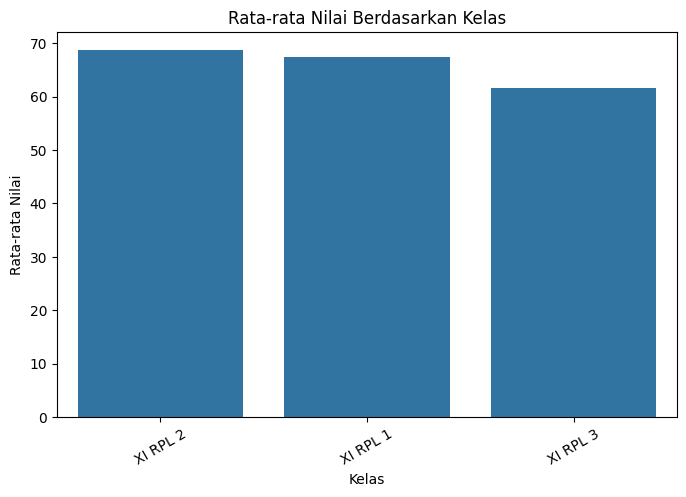

In [ ]:
# grafik rata-rata nilai setiap kelas
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="kelas",
    y="nilai",
    errorbar=None
)

plt.title("Rata-rata Nilai Berdasarkan Kelas")
plt.xlabel("Kelas")
plt.ylabel("Rata-rata Nilai")
plt.xticks(rotation=30)
plt.show()

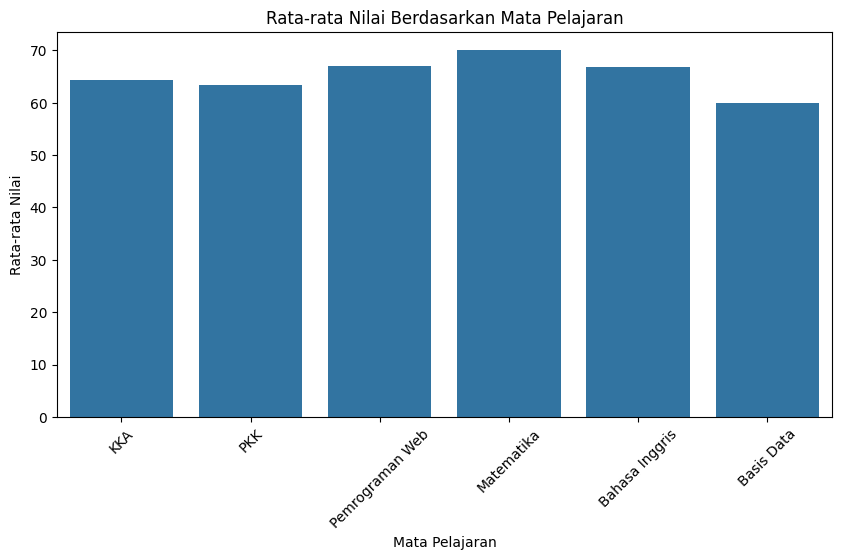

In [ ]:
# grafik rata-rata nilai mata pelajaran
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="mata_pelajaran",
    y="nilai",
    errorbar=None
)

plt.title("Rata-rata Nilai Berdasarkan Mata Pelajaran")
plt.xlabel("Mata Pelajaran")
plt.ylabel("Rata-rata Nilai")
plt.xticks(rotation=45)
plt.show()

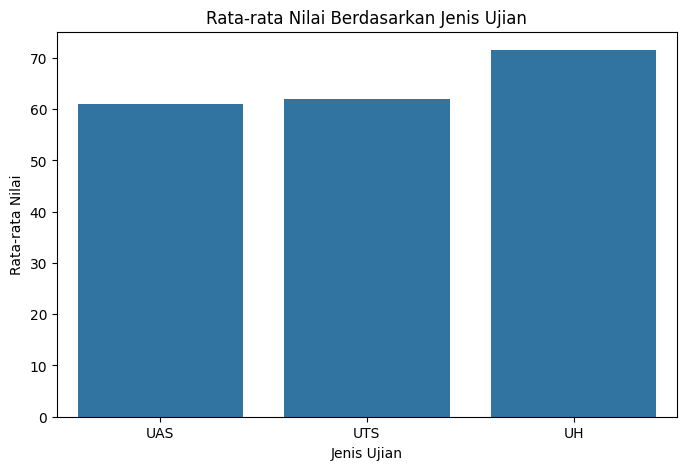

In [ ]:
# grafik berdasarkan jenis ujian
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="jenis_ujian",
    y="nilai",
    errorbar=None
)

plt.title("Rata-rata Nilai Berdasarkan Jenis Ujian")
plt.xlabel("Jenis Ujian")
plt.ylabel("Rata-rata Nilai")
plt.show()

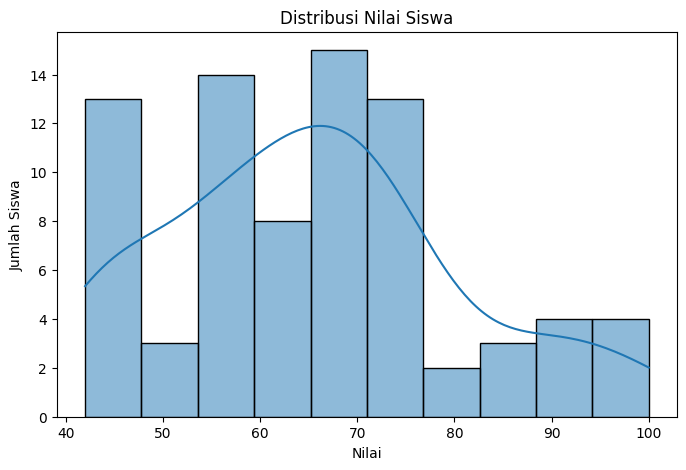

In [ ]:
# grafik penyebaran nilai
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="nilai",
    bins=10,
    kde=True
)

plt.title("Distribusi Nilai Siswa")
plt.xlabel("Nilai")
plt.ylabel("Jumlah Siswa")
plt.show()

In [ ]:
# menyimpan data yang sudah dibersihkan
df.to_excel(
    "dataset_nilai_akademik_siswa_bersih.xlsx",
    index=False
)

print("File berhasil disimpan")

File berhasil disimpan


In [ ]:
from google.colab import files

files.download("dataset_nilai_akademik_siswa_bersih.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>